In [2]:
from chython import smarts
from chython.containers import ReactionContainer


def load_tsv_rules_as_reaction_containers(tsv_path: str) -> tuple[ReactionContainer, ...]:
    rules = []
    with open(tsv_path, encoding="utf-8") as f:
        f.readline()  # skip header
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            rule_smarts = line.split("\t", 1)[0]
            rule = smarts(rule_smarts)
            rules.append(rule)
    return tuple(rules)


reactions_path_a = "../mapping/uspto_full_rules_light_pop_3_uu.tsv"

x = load_tsv_rules_as_reaction_containers(reactions_path_a)

In [ ]:
from synplan.chem.utils import query_to_mol
p = 0
xxx = []
for rule in x:
    react = rule.reactants
    prods = rule.products
    if len (prods) == 1:
        prod = prods[0]
        mol = query_to_mol(prod)
        if len(mol.split()) > 1:
            n = ReactionContainer(react, prod.split())
            print("Multiple products detected in rule; using ReactionContainer.")
            p += 1
        else:
            n = ReactionContainer(react, [prod])
    else:
        n = ReactionContainer(react, prods)
    xxx.append(n)
print(p)

## Analysis

### Number of reactants

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# assumes `x` is your loaded rules (ReactionContainer list/tuple)
product_counts = [len(rq.products) for rq in x]

dist = (
    pd.Series(product_counts, name="n_products")
    .value_counts()
    .sort_index()
    .rename_axis("n_products")
    .reset_index(name="n_rules")
)

display(dist)


,n_products,n_rules
0,1,5414
1,2,37097
2,3,2605
3,4,129
4,5,6


In [4]:
len(x)

45251

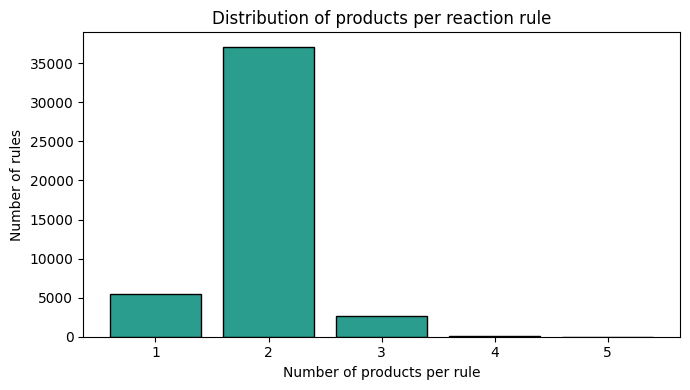

In [5]:

plt.figure(figsize=(7, 4))
plt.bar(dist["n_products"], dist["n_rules"], color="#2a9d8f", edgecolor="black")
plt.xlabel("Number of products per rule")
plt.ylabel("Number of rules")
plt.title("Distribution of products per reaction rule")
plt.xticks(dist["n_products"])
plt.tight_layout()
plt.show()

In [8]:
k = 5  # target number of products

rules_k = [rq for rq in x if len(rq.products) == k]
print(f"{len(rules_k)} rules with {k} products")
qqq = 0
for rq in rules_k[qqq:qqq+20]:   # remove [:20] to show all
    rq.clean2d()
    display(rq)
    print(rq)

6 rules with 5 products


[C;D3:1]-[C;D3:2]-1-[C;D3:4](-[N;D2:5]-[C;D3:6](=[O;D1:7])-[N;D2:10]-1)=[O;D1:11]>>[C;D1-:4]#[N;D1:5].[C;D3:1]-[C;D2:2]=[O;D1:3].[C;D3:6](=[O;D1:7])(-[O;D1-:8])-[O;D1-:9].[N;D0+:10].[O;D0:11]


[O;D1:1]-[C;D3:8](-[C;D4:5](-[O;D2:3]-[C;D3:2])(-[C;D2:4])-[C;D2:7])=[O;D1:12]>>[C;D2:4]-[C;D3:5](=[O;D1:6])-[C;D2:7].[C;D3:2]-[O;D1:3].[C;D3:8](-[Cl;D1:9])(-[Cl;D1:10])-[Cl;D1:11].[O;D0-:1].[O;D2:12]-1-[C;D2:13]-[C;D2:14]-[C;D2:15]-[C;D2:16]-1


[C;D3:1]-[N;D3:2](-[C;D3:3](-[C;D3:5])-[C;D3:16](-[N;D1:15])=[O;D1:25])-[C;D3:7](-[C;D3:6])=[O;D1:9]>>[C:10]:1(-[C:11]-2-[C:12]-[C;D2:13]-[C;D3:14](-[N;D2+:15]#[C;D1-:16])=[C;D2:17]-[C:18]-2):[C:19]:[C:20]:[C:21]:[C:22]:[C:23]:1.[C;D1:24]-[O;D1:25].[C;D2:3](=[O;D1:4])-[C;D3:5].[C;D3:1]-[N;D1:2].[C;D3:6]-[C;D3:7](-[O;D1:8])=[O;D1:9]


[C;D2:1]-[C;D4:2]-1(-[C;D2:3])-[C;D3:4](-[N;D2:5]-[C;D3:6](=[O;D1:7])-[N;D2:8]-1)=[O;D1:9]>>[C;D1-:4]#[N;D1:5].[C;D2:1]-[C;D3:2](-[C;D2:3])=[O;D1:10].[C;D3:6](=[O;D1:7])(-[O;D1-:11])-[O;D1-:12].[N;D0+:8].[O;D0:9]


[C;D3:1]-[C;D3:2](-[C;D3:5](-[O;D1:4])=[O;D1:9])-[O;D2:11]-[C;D1:10]>>[C;D1:10]-[O;D1:11].[C;D3:1]-[C;D2:2]=[O;D1:3].[C;D3:5](-[Br;D1:6])(-[Br;D1:7])-[Br;D1:8].[O;D0-:4].[O;D0-:9]


[C;D3:1]-[C;D4:3]-1(-[C;D3:2])-[C;D3:5](-[N;D2:6]-[C;D3:7](=[O;D1:8])-[N;D2:11]-1)=[O;D1:12]>>[C;D1-:5]#[N;D1:6].[C;D3:1]-[C;D3:3](-[C;D3:2])=[O;D1:4].[C;D3:7](=[O;D1:8])(-[O;D1-:9])-[O;D1-:10].[N;D0+:11].[O;D0:12]


In [ ]:
import pandas as pd

wa = pd.read_csv(reactions_path_a, sep="\t")

qa_smarts = '[C;D3:1]-[C;D4:3]-1(-[C;D3:2])-[C;D3:5](-[N;D2:6]-[C;D3:7](=[O;D1:8])-[N;D2:11]-1)=[O;D1:12]>>[C;D1-:5]#[N;D1:6].[C;D3:1]-[C;D3:3](-[C;D3:2])=[O;D1:4].[C;D3:7](=[O;D1:8])(-[O;D1-:9])-[O;D1-:10].[N;D0+:11].[O;D0:12]'
qa = smarts(qa_smarts)
qa.clean2d()
display(qa)

qwa = wa[wa.rule_smarts == qa_smarts]
qwa

,rule_smarts,popularity,reaction_indices


In [13]:
from functools import lru_cache
import pandas as pd
from chython import smarts, Reactor


def _mapping_renumber(container):
    return {atom_num: i for i, atom_num in enumerate(sorted(list(container)), start=1)}


@lru_cache(maxsize=200_000)
def canonical_rule_key(rule_smarts: str):
    s = (rule_smarts or "").strip()
    if not s:
        return None

    try:
        if ">>" in s:
            rxn = Reactor.from_smarts(s)

            if hasattr(rxn, "_mapping_renumber"):
                renumber = rxn._mapping_renumber()
            else:
                atoms = set()
                for p in rxn._patterns:
                    atoms.update(list(p))
                for p in rxn._products:
                    atoms.update(list(p))
                renumber = {n: i for i, n in enumerate(sorted(atoms), start=1)}

            lhs = tuple(sorted(p.to_smarts(mapping_renumber=renumber) for p in rxn._patterns))
            rhs = tuple(sorted(p.to_smarts(mapping_renumber=renumber) for p in rxn._products))
            return ("rxn", lhs, rhs)

        q = smarts(s)
        return ("qry", q.to_smarts(mapping_renumber=_mapping_renumber(q)))

    except Exception:
        return None


def get_reaction_indices_for_rule(df: pd.DataFrame, rule_of_interest: str):
    if "rule_smarts" not in df.columns:
        raise KeyError("DataFrame must contain 'rule_smarts'")
    if "reaction_indices" not in df.columns:
        raise KeyError("DataFrame must contain 'reaction_indices'")

    target_key = canonical_rule_key(rule_of_interest)
    if target_key is None:
        raise ValueError(f"Cannot parse rule_of_interest: {rule_of_interest!r}")

    row_keys = df["rule_smarts"].map(lambda x: canonical_rule_key(x) if isinstance(x, str) else None)

    # Important: do not use row_keys.eq(target_key) because target_key is a tuple
    # and pandas may try length-aligned comparison.
    mask = row_keys.map(lambda k: k == target_key)

    matched = df.loc[mask, "reaction_indices"]
    if matched.empty:
        return []

    return matched.explode().dropna().tolist()


# Example:
reaction_indices = get_reaction_indices_for_rule(wa, qa_smarts)
print(reaction_indices)


['13480,119672,1185802']


In [19]:
filt_smi_path = '../mapping/uspto_filtered_light.smi'

filt_smi = pd.read_csv(filt_smi_path, header=None, names=['smiles', 'annotation'])
filt_smi

ParserError: Error tokenizing data. C error: Expected 2 fields in line 17138, saw 4


### Special atoms

In [ ]:
# assumes `x` is a list/tuple of ReactionContainer rules
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

base_atoms = {"C", "N", "O", "H"}

# collect special atoms per rule
rule_special_elems = []
for rq in x:
    elems = set()
    for mol in (*rq.reactants, *rq.products):
        for _, atom in mol.atoms():
            sym = getattr(atom, "atomic_symbol", None)
            if sym and sym not in base_atoms:
                elems.add(sym)
    rule_special_elems.append(elems)

# rules that have at least one special atom
rules_with_special = [rq for rq, elems in zip(x, rule_special_elems) if elems]
print(f"Rules with special atoms: {len(rules_with_special)} / {len(x)}")

# distribution: how many rules contain each special atom type
element_counts = Counter(sym for elems in rule_special_elems for sym in elems)
dist = (
    pd.Series(element_counts, name="n_rules")
    .sort_values(ascending=False)
    .rename_axis("element")
    .reset_index()
)
display(dist)


Rules with special atoms: 27903 / 45255


,element,n_rules
0,Cl,10318
1,S,8612
2,Br,7648
3,B,2916
4,I,2629
5,F,2578
6,P,1276
7,Si,955
8,Mg,522
9,Sn,476


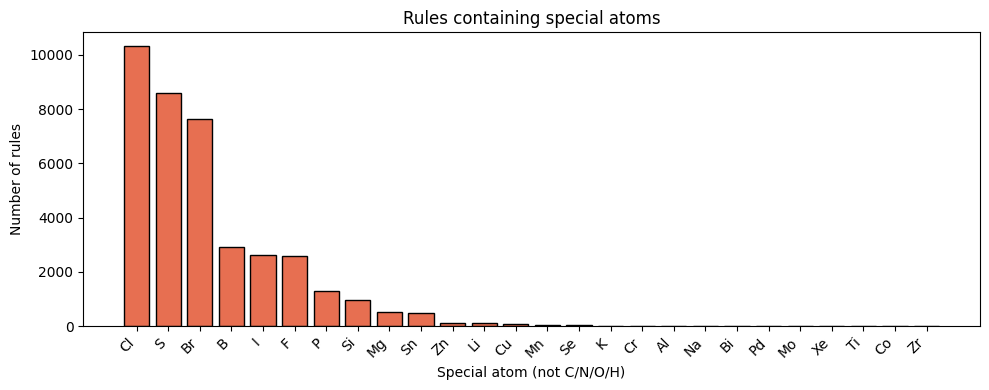

In [ ]:
# plot distribution by special atom type
plt.figure(figsize=(10, 4))
plt.bar(dist["element"], dist["n_rules"], color="#e76f51", edgecolor="black")
plt.xlabel("Special atom (not C/N/O/H)")
plt.ylabel("Number of rules")
plt.title("Rules containing special atoms")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
for rq in rules_with_special[-20:]:
    rq.clean2d()
    display(rq)

In [ ]:
# ADDED S, Cl, Br

base_atoms = {"C", "N", "O", "H", "S", "Br", "Cl", 'B',
 'I',
 'F',
 'P',
 'Si',
 'Mg',
 'Sn',
 'Zn',
 'Li',
 'Cu',
 'Mn',
 'Se',
 'K',
 'Cr'}

# collect special atoms per rule
rule_special_elems = []
for rq in x:
    elems = set()
    for mol in (*rq.reactants, *rq.products):
        for _, atom in mol.atoms():
            sym = getattr(atom, "atomic_symbol", None)
            if sym and sym not in base_atoms:
                elems.add(sym)
    rule_special_elems.append(elems)

# rules that have at least one special atom
rules_with_special = [rq for rq, elems in zip(x, rule_special_elems) if elems]
print(f"Rules with special atoms: {len(rules_with_special)} / {len(x)}")

# distribution: how many rules contain each special atom type
element_counts = Counter(sym for elems in rule_special_elems for sym in elems)
dist = (
    pd.Series(element_counts, name="n_rules")
    .sort_values(ascending=False)
    .rename_axis("element")
    .reset_index()
)
display(dist)


Rules with special atoms: 25 / 45255


,element,n_rules
0,Al,8
1,Na,5
2,Bi,3
3,Pd,2
4,Mo,2
5,Xe,2
6,Ti,1
7,Co,1
8,Zr,1


In [ ]:
for rq in rules_with_special[:25]:
    rq.clean2d()
    display(rq)

### Uniqueness

In [ ]:
from collections import Counter, defaultdict
import pandas as pd
from tqdm.auto import tqdm
from synplan.chem.utils import cgr_from_reaction_rule

# x: list/tuple of ReactionContainer rules

def canonical_smarts_key(rule):
    # Canonical query-reaction serialization from chython
    return str(rule)

def canonical_cgr_key(rule):
    # Canonical CGR serialization
    return str(cgr_from_reaction_rule(rule))

def build_duplicate_report(keys, label="key"):
    cnt = Counter(keys)
    total = len(keys)
    unique = len(cnt)
    dup_keys = sum(1 for v in cnt.values() if v > 1)
    dup_instances = sum(v - 1 for v in cnt.values() if v > 1)

    groups = defaultdict(list)
    for i, k in enumerate(keys):
        groups[k].append(i)
    dup_groups = {k: idxs for k, idxs in groups.items() if len(idxs) > 1}

    summary = pd.DataFrame([{
        "type": label,
        "total_rules": total,
        "unique_rules": unique,
        "duplicate_keys": dup_keys,
        "duplicate_instances": dup_instances,
        "uniqueness_ratio": unique / total if total else 0.0,
    }])

    top_dups = pd.DataFrame(
        [{"key": k, "count": len(v), "indices": v[:10]} for k, v in dup_groups.items()]
    ).sort_values("count", ascending=False) if dup_groups else pd.DataFrame(columns=["key", "count", "indices"])

    return summary, top_dups, dup_groups

# 1) Canonical SMARTS duplicates (exact rule-string identity after canonical serialization)
smarts_keys = [canonical_smarts_key(rq) for rq in tqdm(x, desc="Canonical SMARTS")]
smarts_summary, smarts_top_dups, smarts_dup_groups = build_duplicate_report(smarts_keys, "canonical_smarts")
display(smarts_summary)
display(smarts_top_dups.head(20))

# 2) Canonical CGR duplicates
cgr_keys = []
cgr_fail_idx = []
for i, rq in enumerate(tqdm(x, desc="Canonical CGR")):
    try:
        cgr_keys.append(canonical_cgr_key(rq))
    except Exception:
        cgr_keys.append(None)
        cgr_fail_idx.append(i)

valid_cgr_keys = [k for k in cgr_keys if k is not None]
cgr_summary, cgr_top_dups, cgr_dup_groups = build_duplicate_report(valid_cgr_keys, "canonical_cgr")
cgr_summary["failed_cgr_conversion"] = len(cgr_fail_idx)
display(cgr_summary)
display(cgr_top_dups.head(20))

print("CGR conversion failures:", len(cgr_fail_idx))


Canonical SMARTS:   0%|          | 0/45255 [00:00<?, ?it/s]

,type,total_rules,unique_rules,duplicate_keys,duplicate_instances,uniqueness_ratio
0,canonical_smarts,45255,45149,106,106,0.997658


,key,count,indices
0,[C;D3:1]-[C;D3:2](=[O;D1:4])-[N;D3:6](-[C;D2:5...,2,"[7, 38756]"
1,[N;D2:1](-[C;D3:2])-[C;D3:4](-[C;D3:3])=[O;D1:...,2,"[19, 3506]"
2,[C;D3:1]-[N;D2:2]-[C;D3:4](-[C;D3:3])=[O;D1:6]...,2,"[20, 21375]"
3,[C;D3:1]-[C;D3:2](=[O;D1:4])-[O;D2:6]-[C;D2:5]...,2,"[38, 22275]"
4,[N;D2:1](-[C;D3:2])-[C;D3:4](-[C;D3:3])=[O;D1:...,2,"[64, 2837]"
5,[C;D2:1]-[N;D3:2](-[C;D2:3])-[C;D3:5](-[C;D2:4...,2,"[76, 32909]"
6,[C;D3:1]-[O;D2:2]-[C;D2:4]-[C;D2:3]>>[C;D2:3]-...,2,"[88, 3138]"
7,[N;D2:1](-[C;D3:2])-[C;D3:4](-[C;D2:3])=[O;D1:...,2,"[107, 7444]"
8,[C;D3:1]-[C;D3:2](=[O;D1:4])-[N;D3:6](-[C;D2:5...,2,"[132, 14165]"
9,[N;D2:1](-[C;D2:2])-[C;D3:4](-[C;D3:3])=[O;D1:...,2,"[133, 9819]"


Canonical CGR:   0%|          | 0/45255 [00:00<?, ?it/s]

,type,total_rules,unique_rules,duplicate_keys,duplicate_instances,uniqueness_ratio,failed_cgr_conversion
0,canonical_cgr,45215,12768,5348,32447,0.282384,40


,key,count,indices
52,CN(C)[->.]C(C)[.>-]Br,273,"[120, 141, 162, 184, 195, 241, 256, 258, 333, ..."
96,CN(C)[->.]C([.>-]Cl)(N)C,256,"[285, 299, 405, 470, 559, 610, 620, 641, 646, ..."
80,CC(C)([.>-]Br)[->.]N(C)C,242,"[233, 355, 397, 682, 715, 883, 925, 1051, 1080..."
55,CN(C)[->.]C([.>-]Cl)(C)=O,216,"[125, 270, 300, 321, 332, 358, 420, 642, 651, ..."
72,Cl[.>-]C(N)(C)[->.]NC,188,"[206, 228, 240, 264, 292, 303, 380, 454, 513, ..."
4,CN(C)[->.]C(C)(=O)[.>-]O,179,"[7, 27, 30, 31, 47, 76, 110, 122, 132, 161]"
120,CN(C)[->.]C(C)(C)[.>-]F,175,"[391, 489, 569, 1124, 1313, 1339, 1388, 1398, ..."
19,Cl[.>-]C(=O)(C)[->.]NC,172,"[42, 51, 61, 99, 155, 160, 172, 198, 212, 230]"
2,C([.>-]O)(=O)(C)[->.]NC,160,"[2, 4, 6, 14, 19, 20, 25, 39, 48, 58]"
142,CC(C)([->.]NC)[.>=]O,154,"[517, 600, 612, 796, 1173, 1533, 1578, 1723, 1..."


CGR conversion failures: 40


In [ ]:
x[8994]

In [ ]:
x[538]

### Ring transformation

how often rules create rings, open rings, or change aromaticity.

In [ ]:
# Whole script: center-aware ring/aromatic transformation stats
# Works with `x` = list/tuple of ReactionContainer rules (query rules)

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from synplan.chem.utils import reaction_query_to_reaction

# If your rules are RETRO and you want FORWARD labels in outputs, keep True
RETRO_RULES = True

def ring_bond_set(molecules):
    """Unordered atom-map pairs for bonds that belong to SSSR rings."""
    edges = set()
    for mol in molecules:
        for ring in mol.sssr:
            ring = list(ring)
            for a, b in zip(ring, ring[1:] + ring[:1]):
                edges.add(tuple(sorted((a, b))))
    return edges

def aromatic_bond_set(molecules):
    """Unordered atom-map pairs for aromatic bonds (order=4)."""
    edges = set()
    for mol in molecules:
        for a, b, bond in mol.bonds():
            if getattr(bond, "order", None) == 4:
                edges.add(tuple(sorted((a, b))))
    return edges

def ring_size_signature_near_center(molecules, center_atoms):
    """Sorted tuple of ring sizes for rings touching reaction center."""
    sizes = []
    for mol in molecules:
        for ring in mol.sssr:
            if set(ring) & center_atoms:
                sizes.append(len(ring))
    return tuple(sorted(sizes))
# --- ring-size change with majority-atom matching ---

def rings_near_center(molecules, center_atoms):
    """Return list of ring atom sets for rings touching reaction center."""
    out = []
    for mol in molecules:
        for ring in mol.sssr:
            atoms = set(ring)
            if atoms & center_atoms:
                out.append(atoms)
    return out


def match_rings_by_majority_overlap(r_rings, p_rings, majority=0.5):
    """
    Match reactant/product rings only if BOTH sides keep majority atoms:
      |R ∩ P| / |R| > majority and |R ∩ P| / |P| > majority
    """
    candidates = []
    for i, r_atoms in enumerate(r_rings):
        for j, p_atoms in enumerate(p_rings):
            inter = len(r_atoms & p_atoms)
            if inter == 0:
                continue
            if (inter / len(r_atoms) > majority) and (inter / len(p_atoms) > majority):
                # score: prefer higher overlap
                score = inter / max(len(r_atoms), len(p_atoms))
                candidates.append((score, inter, i, j))

    # greedy one-to-one matching by best score
    candidates.sort(reverse=True)
    used_r, used_p, matches = set(), set(), []
    for _, inter, i, j in candidates:
        if i in used_r or j in used_p:
            continue
        used_r.add(i)
        used_p.add(j)
        matches.append((i, j, inter))
    return matches, used_r, used_p


def classify_ring_size_change_majority(
    reactants, products, center_atoms, retro=False, majority=0.5
):
    r_rings = rings_near_center(reactants, center_atoms)
    p_rings = rings_near_center(products, center_atoms)

    if not r_rings and not p_rings:
        out = "unchanged"
    else:
        matches, used_r, used_p = match_rings_by_majority_overlap(
            r_rings, p_rings, majority=majority
        )

        increased = 0
        decreased = 0
        for i, j, _ in matches:
            rs = len(r_rings[i])
            ps = len(p_rings[j])
            if ps > rs:
                increased += 1
            elif ps < rs:
                decreased += 1

        unmatched_r = len(r_rings) - len(used_r)
        unmatched_p = len(p_rings) - len(used_p)

        # strict classification: only matched related rings can drive inc/dec
        if increased == 0 and decreased == 0 and unmatched_r == 0 and unmatched_p == 0:
            out = "unchanged"
        elif increased > 0 and decreased == 0 and unmatched_r == 0 and unmatched_p == 0:
            out = "increased"
        elif decreased > 0 and increased == 0 and unmatched_r == 0 and unmatched_p == 0:
            out = "decreased"
        else:
            out = "other"

    # if retro rules but you want forward labels
    if retro:
        if out == "increased":
            out = "decreased"
        elif out == "decreased":
            out = "increased"

    return out


rows = []
failed = []

for i, rq in enumerate(tqdm(x, desc="Analyzing ring/aromatic transformations")):
    try:
        rxn = reaction_query_to_reaction(rq)
        cgr = ~rxn
        center = set(cgr.center_atoms)

        # only truly changed bonds
        dynamic_bonds = {
            tuple(sorted((a, b)))
            for a, b, bond in cgr.bonds()
            if bond.order != bond.p_order
        }

        # ring bond changes
        r_ring = ring_bond_set(rxn.reactants)
        p_ring = ring_bond_set(rxn.products)
        ring_bonds_lost = (r_ring - p_ring) & dynamic_bonds
        ring_bonds_gained = (p_ring - r_ring) & dynamic_bonds

        # Labels (forward meaning if RETRO_RULES=True)
        if RETRO_RULES:
            ring_created = bool(ring_bonds_lost)
            ring_opened = bool(ring_bonds_gained)
        else:
            ring_created = bool(ring_bonds_gained)
            ring_opened = bool(ring_bonds_lost)

        # ring-size change near center
        r_sig = ring_size_signature_near_center(rxn.reactants, center)
        p_sig = ring_size_signature_near_center(rxn.products, center)
        ring_size_change_type = classify_ring_size_change(r_sig, p_sig, retro=RETRO_RULES)

        # aromaticity changes on dynamic bonds
        arom_to_non = 0
        non_to_arom = 0
        for a, b, bond in cgr.bonds():
            old, new = bond.order, bond.p_order
            if old == new:
                continue
            if old == 4 and new != 4:
                arom_to_non += 1
            elif old != 4 and new == 4:
                non_to_arom += 1

        aromatic_changed = (arom_to_non + non_to_arom) > 0

        rows.append({
            "rule_idx": i,
            "ring_created": ring_created,
            "ring_opened": ring_opened,
            "ring_size_change_type": ring_size_change_type,   # unchanged/increased/decreased/other
            "ring_size_changed": ring_size_change_type != "unchanged",
            "aromatic_changed": aromatic_changed,
            "aromatization": non_to_arom > 0,
            "dearomatization": arom_to_non > 0,
            "n_ring_bonds_gained": len(ring_bonds_gained),
            "n_ring_bonds_lost": len(ring_bonds_lost),
            "n_arom_bonds_to_arom": non_to_arom,
            "n_arom_bonds_from_arom": arom_to_non,
        })

    except Exception as e:
        failed.append((i, str(e)))

df = pd.DataFrame(rows)

print(f"Total rules: {len(x)}")
print(f"Analyzed: {len(df)}")
print(f"Failed: {len(failed)}")

# Event summary
summary_events = pd.DataFrame({
    "event": [
        "ring_created",
        "ring_opened",
        "ring_size_changed",
        "aromatic_changed",
        "aromatization",
        "dearomatization",
    ],
    "n_rules": [
        int(df["ring_created"].sum()),
        int(df["ring_opened"].sum()),
        int(df["ring_size_changed"].sum()),
        int(df["aromatic_changed"].sum()),
        int(df["aromatization"].sum()),
        int(df["dearomatization"].sum()),
    ],
})
summary_events["pct_of_analyzed"] = (100 * summary_events["n_rules"] / max(len(df), 1)).round(2)
display(summary_events)

# Ring-size segmentation summary
size_seg = (
    df["ring_size_change_type"]
    .value_counts()
    .reindex(["increased", "decreased", "other", "unchanged"], fill_value=0)
    .rename_axis("ring_size_change_type")
    .reset_index(name="n_rules")
)
size_seg["pct_of_analyzed"] = (100 * size_seg["n_rules"] / max(len(df), 1)).round(2)
display(size_seg)

Analyzing ring/aromatic transformations:   0%|          | 0/45255 [00:00<?, ?it/s]

Total rules: 45255
Analyzed: 45215
Failed: 40


,event,n_rules,pct_of_analyzed
0,ring_created,5820,12.87
1,ring_opened,1820,4.03
2,ring_size_changed,9105,20.14
3,aromatic_changed,4834,10.69
4,aromatization,1064,2.35
5,dearomatization,3976,8.79


,ring_size_change_type,n_rules,pct_of_analyzed
0,increased,96,0.21
1,decreased,47,0.10
2,other,8962,19.82
3,unchanged,36110,79.86


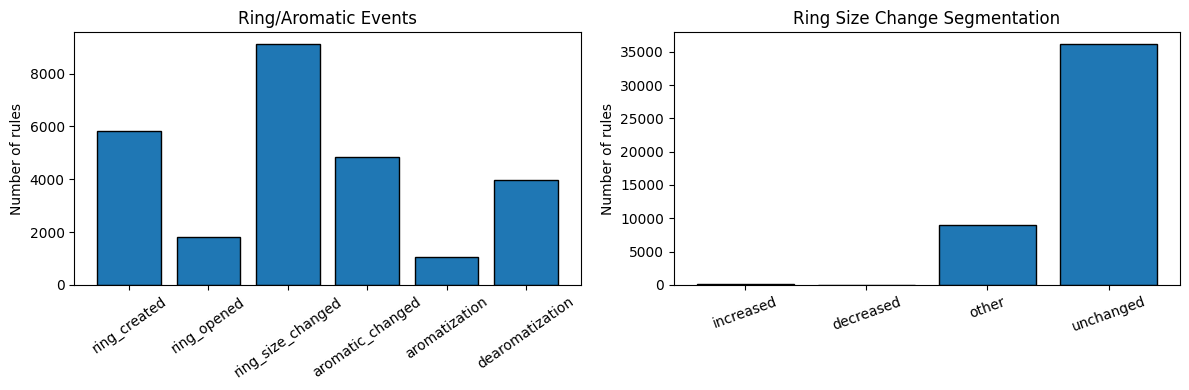

In [ ]:
# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(summary_events["event"], summary_events["n_rules"], edgecolor="black")
ax[0].set_title("Ring/Aromatic Events")
ax[0].set_ylabel("Number of rules")
ax[0].tick_params(axis="x", rotation=35)

ax[1].bar(size_seg["ring_size_change_type"], size_seg["n_rules"], edgecolor="black")
ax[1].set_title("Ring Size Change Segmentation")
ax[1].set_ylabel("Number of rules")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [ ]:

# Optional: indices to inspect
idx_increased = df.loc[df["ring_size_change_type"] == "increased", "rule_idx"].tolist()
idx_decreased = df.loc[df["ring_size_change_type"] == "decreased", "rule_idx"].tolist()
idx_other = df.loc[df["ring_size_change_type"] == "other", "rule_idx"].tolist()
print(f"Rules with increased ring size near center: {len(idx_increased)}")
print(f"Rules with decreased ring size near center: {len(idx_decreased)}")
print(f"Rules with other ring size changes near center: {len(idx_other)}")

Rules with increased ring size near center: 96
Rules with decreased ring size near center: 47
Rules with other ring size changes near center: 8962


In [ ]:
idx_increased

[7709,
 9056,
 9308,
 11958,
 13646,
 13697,
 13716,
 15122,
 15923,
 16225,
 16606,
 16965,
 17546,
 17963,
 18245,
 19198,
 19993,
 20201,
 20203,
 20728,
 21336,
 21900,
 22331,
 23780,
 23826,
 23914,
 24140,
 24282,
 24678,
 25033,
 25737,
 26189,
 26430,
 26431,
 26834,
 26945,
 27068,
 27788,
 27909,
 28491,
 29271,
 29391,
 29749,
 30594,
 30595,
 30888,
 30986,
 31061,
 31251,
 31609,
 33157,
 33566,
 33880,
 33986,
 34022,
 34356,
 34362,
 34422,
 34485,
 34863,
 35176,
 35604,
 36296,
 36448,
 36778,
 36948,
 37117,
 37344,
 37396,
 37639,
 37709,
 38341,
 39882,
 40153,
 40359,
 40516,
 41118,
 41216,
 41429,
 42279,
 42687,
 42732,
 42867,
 42875,
 42932,
 43245,
 43511,
 43608,
 43703,
 43712,
 44563,
 44564,
 44582,
 44643,
 45162,
 45163]

In [ ]:
x[21900]

ValueError: min() arg is an empty sequence

In [ ]:
idx_decreased

[8752,
 14729,
 17627,
 17797,
 20125,
 22862,
 24761,
 25260,
 25532,
 26084,
 27099,
 27620,
 27656,
 27976,
 28190,
 28438,
 28470,
 28958,
 29308,
 29309,
 29310,
 30170,
 30238,
 31538,
 31897,
 32341,
 33001,
 34923,
 35908,
 36742,
 37463,
 37540,
 37555,
 38262,
 38422,
 38599,
 39017,
 39763,
 40271,
 40383,
 41311,
 41817,
 41940,
 42588,
 42729,
 43234,
 44850]

In [ ]:
for d in idx_decreased[:20]:  # remove [:20] to show all
    print(f"Rule index {d}")
    display(x[d])

Rule index 8752


Rule index 14729


Rule index 17627


Rule index 17797


Rule index 20125


Rule index 22862


Rule index 24761


Rule index 25260


Rule index 25532


Rule index 26084


Rule index 27099


Rule index 27620


Rule index 27656


Rule index 27976


Rule index 28190


Rule index 28438


Rule index 28470


Rule index 28958


Rule index 29308


Rule index 29309


In [ ]:
s = df[df['ring_created'] == True]
s

,rule_idx,ring_created,ring_opened,ring_size_changed,aromatic_changed,aromatization,dearomatization,n_arom_bonds_to_arom,n_arom_bonds_from_arom
158,158,True,False,True,True,False,True,0,5
512,512,True,False,True,True,False,True,0,5
653,653,True,False,True,False,False,False,0,0
667,667,True,False,True,True,False,True,0,5
704,704,True,False,True,True,False,True,0,5
...,...,...,...,...,...,...,...,...,...
45166,45206,True,False,True,True,False,True,0,5
45176,45216,True,False,True,True,False,True,0,3
45196,45236,True,False,True,True,False,True,0,5
45201,45241,True,False,True,True,False,True,0,4


In [ ]:
x[158]

In [ ]:
pp = df[df['ring_size_changed'] == True]
ppp = pp[pp['ring_created'] == False]
ppp

,rule_idx,ring_created,ring_opened,ring_size_changed,aromatic_changed,aromatization,dearomatization,n_arom_bonds_to_arom,n_arom_bonds_from_arom
44,44,False,False,True,False,False,False,0,0
86,86,False,True,True,False,False,False,0,0
123,123,False,False,True,False,False,False,0,0
144,144,False,False,True,False,False,False,0,0
166,166,False,True,True,False,False,False,0,0
...,...,...,...,...,...,...,...,...,...
45171,45211,False,False,True,False,False,False,0,0
45181,45221,False,True,True,True,True,False,5,0
45193,45233,False,False,True,False,False,False,0,0
45197,45237,False,False,True,False,False,False,0,0


In [ ]:
x[45240]

In [ ]:
failed

[(1164, "'Bond' object has no attribute '_in_ring'"),
 (1307, "'Bond' object has no attribute '_in_ring'"),
 (2160, "'Bond' object has no attribute '_in_ring'"),
 (3717, "'Bond' object has no attribute '_in_ring'"),
 (4591, "'Bond' object has no attribute '_in_ring'"),
 (5174, "'Bond' object has no attribute '_in_ring'"),
 (5486, "'Bond' object has no attribute '_in_ring'"),
 (5889, "'Bond' object has no attribute '_in_ring'"),
 (5990, "'Bond' object has no attribute '_in_ring'"),
 (7956, "'Bond' object has no attribute '_in_ring'"),
 (8546, "'Bond' object has no attribute '_in_ring'"),
 (9128, "'Bond' object has no attribute '_in_ring'"),
 (9249, "'Bond' object has no attribute '_in_ring'"),
 (9995, "'Bond' object has no attribute '_in_ring'"),
 (12699, "'Bond' object has no attribute '_in_ring'"),
 (13060, "'Bond' object has no attribute '_in_ring'"),
 (14800, "'Bond' object has no attribute '_in_ring'"),
 (16537, "'Bond' object has no attribute '_in_ring'"),
 (16607, "'Bond' object 

In [ ]:
for idx, err in failed:
    print(f"Rule index {idx}")
    display(x[idx])


Rule index 1164


Rule index 1307


Rule index 2160


Rule index 3717


Rule index 4591


Rule index 5174


Rule index 5486


Rule index 5889


Rule index 5990


Rule index 7956


Rule index 8546


Rule index 9128


Rule index 9249


Rule index 9995


Rule index 12699


Rule index 13060


Rule index 14800


Rule index 16537


Rule index 16607


Rule index 16709


Rule index 17599


Rule index 18701


Rule index 20242


Rule index 21358


Rule index 21438


Rule index 22219


Rule index 23496


Rule index 24858


Rule index 29999


Rule index 31286


Rule index 31837


Rule index 37493


Rule index 38461


Rule index 39019


Rule index 39137


Rule index 40108


Rule index 40913


Rule index 43269


Rule index 43394


Rule index 43482


### Reaction-center size

counts of bonds broken, formed, and bond-order changes per rule.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from synplan.chem.utils import reaction_query_to_reaction

# x: tuple/list of ReactionContainer rules

rows = []
failed = []

for i, rq in enumerate(tqdm(x, desc="Reaction-center size")):
    try:
        rxn = reaction_query_to_reaction(rq)
        cgr = ~rxn

        # mapped atoms with real changes (bond/charge/radical)
        center_atoms = set(cgr.center_atoms)

        # mapped bonds with real dynamic changes (formed/broken/order-changed)
        center_bonds = {tuple(sorted((a, b))) for a, b in cgr.center_bonds}

        rows.append(
            {
                "rule_idx": i,
                "n_center_atoms": len(center_atoms),
                "n_center_bonds": len(center_bonds),
                "center_atoms": tuple(sorted(center_atoms)),
                "center_bonds": tuple(sorted(center_bonds)),
            }
        )
    except Exception as e:
        failed.append((i, str(e)))

df_center = pd.DataFrame(rows)

print("total rules:", len(x))
print("analyzed:", len(df_center))
print("failed:", len(failed))

# distributions
dist_atoms = df_center["n_center_atoms"].value_counts().sort_index()
dist_bonds = df_center["n_center_bonds"].value_counts().sort_index()

display(pd.DataFrame({"n_center_atoms": dist_atoms.index, "n_rules": dist_atoms.values}))
display(pd.DataFrame({"n_center_bonds": dist_bonds.index, "n_rules": dist_bonds.values}))

Reaction-center size:   0%|          | 0/45255 [00:00<?, ?it/s]

total rules: 45255
analyzed: 45215
failed: 40


,n_center_atoms,n_rules
0,1,1
1,2,2984
2,3,21018
3,4,9422
4,5,4053
5,6,2495
6,7,2621
7,8,1292
8,9,773
9,10,294


,n_center_bonds,n_rules
0,0,1
1,1,2993
2,2,21414
3,3,9457
4,4,4206
5,5,1747
6,6,1923
7,7,1811
8,8,808
9,9,510


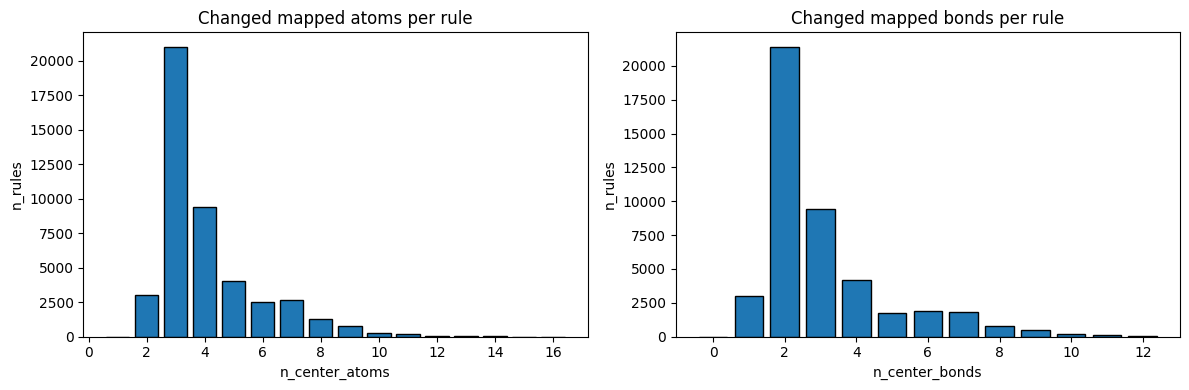

In [ ]:
# plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(dist_atoms.index, dist_atoms.values, edgecolor="black")
ax[0].set_title("Changed mapped atoms per rule")
ax[0].set_xlabel("n_center_atoms")
ax[0].set_ylabel("n_rules")

ax[1].bar(dist_bonds.index, dist_bonds.values, edgecolor="black")
ax[1].set_title("Changed mapped bonds per rule")
ax[1].set_xlabel("n_center_bonds")
ax[1].set_ylabel("n_rules")

plt.tight_layout()
plt.show()


### Multi-center reaction


In [ ]:
# Identify multi-center reaction rules
# Assumes `x` is your list/tuple of ReactionContainer rules.

from synplan.chem.utils import reaction_query_to_reaction
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# Set to 2 if you want to ignore 1-atom center components (often charge-only)
MIN_CENTER_COMPONENT_SIZE = 1

rows = []
failed = []

for i, rq in enumerate(tqdm(x, desc="Detecting multi-center rules")):
    try:
        rxn = reaction_query_to_reaction(rq)
        cgr = ~rxn

        components = [
            tuple(sorted(comp))
            for comp in cgr.centers_list
            if len(comp) >= MIN_CENTER_COMPONENT_SIZE
        ]

        rows.append(
            {
                "rule_idx": i,
                "n_centers": len(components),
                "center_sizes": tuple(sorted(len(c) for c in components)),
                "center_components": components,
                "n_center_atoms_total": len(set(cgr.center_atoms)),
                "n_center_bonds_total": len(cgr.center_bonds),
            }
        )
    except Exception as e:
        failed.append((i, str(e)))

df_centers = pd.DataFrame(rows)

# Multi-center = more than one disconnected reaction-center component
multi_df = df_centers[df_centers["n_centers"] > 1].copy()
multi_rule_indices = multi_df["rule_idx"].tolist()

print(f"Total rules: {len(x)}")
print(f"Analyzed: {len(df_centers)}")
print(f"Failed: {len(failed)}")
print(f"Multi-center rules: {len(multi_df)}")

# Distribution of number of center components
dist = df_centers["n_centers"].value_counts().sort_index()
display(
    pd.DataFrame({"n_centers": dist.index, "n_rules": dist.values})
)

Detecting multi-center rules:   0%|          | 0/45255 [00:00<?, ?it/s]

Total rules: 45255
Analyzed: 45215
Failed: 40
Multi-center rules: 3245


,n_centers,n_rules
0,1,41970
1,2,2962
2,3,269
3,4,13
4,5,1


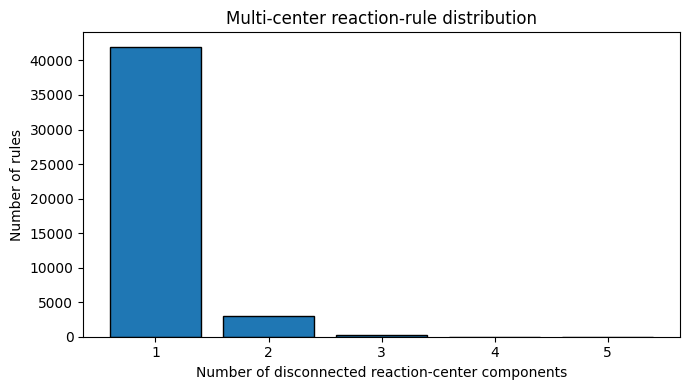

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(dist.index, dist.values, edgecolor="black")
plt.xlabel("Number of disconnected reaction-center components")
plt.ylabel("Number of rules")
plt.title("Multi-center reaction-rule distribution")
plt.tight_layout()
plt.show()


In [ ]:
# Optional: inspect first N multi-center rules
N = 10
for _, row in multi_df.head(N).iterrows():
    idx = int(row["rule_idx"])
    print(f"rule_idx={idx}, n_centers={row['n_centers']}, center_sizes={row['center_sizes']}")
    x[idx].clean2d()
    display(x[idx])


rule_idx=730, n_centers=2, center_sizes=(2, 3)


rule_idx=746, n_centers=2, center_sizes=(2, 2)


rule_idx=885, n_centers=2, center_sizes=(2, 2)


rule_idx=922, n_centers=2, center_sizes=(2, 2)


rule_idx=960, n_centers=2, center_sizes=(2, 3)


rule_idx=1038, n_centers=3, center_sizes=(2, 2, 4)


rule_idx=1041, n_centers=2, center_sizes=(2, 3)


rule_idx=1053, n_centers=2, center_sizes=(2, 3)


rule_idx=1226, n_centers=2, center_sizes=(2, 2)


rule_idx=1269, n_centers=2, center_sizes=(2, 3)


In [ ]:
multi_df[multi_df['n_centers'] == 3]

,rule_idx,n_centers,center_sizes,center_components,n_center_atoms_total,n_center_bonds_total
1038,1038,3,"(2, 2, 4)","[(1, 2, 5, 10), (6, 7), (8, 9)]",8,5
1495,1497,3,"(2, 2, 4)","[(1, 2, 5, 14), (6, 7), (10, 11)]",8,5
2607,2610,3,"(2, 2, 4)","[(1, 2, 5, 10), (6, 7), (14, 15)]",8,5
2715,2718,3,"(2, 2, 4)","[(1, 2, 7, 10), (5, 6), (8, 9)]",8,5
3069,3072,3,"(2, 2, 4)","[(1, 2, 5, 10), (6, 7), (8, 9)]",8,5
...,...,...,...,...,...,...
44987,45027,3,"(2, 2, 4)","[(1, 10), (5, 8, 11, 17), (7, 12)]",8,5
44988,45028,3,"(2, 2, 4)","[(1, 11), (5, 9, 12, 18), (7, 13)]",8,5
45071,45111,3,"(2, 4, 8)","[(1, 14, 15, 32), (3, 4, 5, 6, 7, 8, 12, 24), ...",14,11
45122,45162,3,"(2, 3, 3)","[(2, 3, 15), (5, 13, 14), (6, 7)]",8,5


In [ ]:
x[45162]

In [ ]:
x[45163]

In [ ]:
x[45111]

In [ ]:
z = multi_df[multi_df['n_centers'] == 3]
z

,rule_idx,n_centers,center_sizes,center_components,n_center_atoms_total,n_center_bonds_total
1038,1038,3,"(2, 2, 4)","[(1, 2, 5, 10), (6, 7), (8, 9)]",8,5
1495,1497,3,"(2, 2, 4)","[(1, 2, 5, 14), (6, 7), (10, 11)]",8,5
2607,2610,3,"(2, 2, 4)","[(1, 2, 5, 10), (6, 7), (14, 15)]",8,5
2715,2718,3,"(2, 2, 4)","[(1, 2, 7, 10), (5, 6), (8, 9)]",8,5
3069,3072,3,"(2, 2, 4)","[(1, 2, 5, 10), (6, 7), (8, 9)]",8,5
...,...,...,...,...,...,...
44987,45027,3,"(2, 2, 4)","[(1, 10), (5, 8, 11, 17), (7, 12)]",8,5
44988,45028,3,"(2, 2, 4)","[(1, 11), (5, 9, 12, 18), (7, 13)]",8,5
45071,45111,3,"(2, 4, 8)","[(1, 14, 15, 32), (3, 4, 5, 6, 7, 8, 12, 24), ...",14,11
45122,45162,3,"(2, 3, 3)","[(2, 3, 15), (5, 13, 14), (6, 7)]",8,5


In [ ]:
for pppp in z['rule_idx'][-20:]:
    print(f"rule_idx={pppp}")
    x[pppp].clean2d()
    display(x[pppp])
    

rule_idx=43869


rule_idx=44178


rule_idx=44222


rule_idx=44352


rule_idx=44354


rule_idx=44399


rule_idx=44650


rule_idx=44708


rule_idx=44750


rule_idx=44751


rule_idx=44822


rule_idx=44884


rule_idx=44930


rule_idx=44989


rule_idx=45007


rule_idx=45027


rule_idx=45028


rule_idx=45111


rule_idx=45162


rule_idx=45163


In [ ]:
def has_boron(rule):
    for mol in (*rule.reactants, *rule.products):
        for _, atom in mol.atoms():
            if getattr(atom, "atomic_symbol", None) == "B":
                return True
    return False

# flag boron presence (uses rule_idx from z to access x)
z["has_boron"] = z["rule_idx"].map(lambda i: has_boron(x[int(i)]))

# stats
n_total = len(z)
n_boron = int(z["has_boron"].sum())
n_no_boron = n_total - n_boron

print(f"Total rules in z: {n_total}")
print(f"With boron: {n_boron} ({(100*n_boron/max(n_total,1)):.2f}%)")
print(f"Without boron: {n_no_boron} ({(100*n_no_boron/max(n_total,1)):.2f}%)")

display(z["has_boron"].value_counts(dropna=False).rename_axis("has_boron").reset_index(name="n_rules"))


Total rules in z: 269
With boron: 131 (48.70%)
Without boron: 138 (51.30%)


/tmp/ipykernel_2421793/4259617901.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  z["has_boron"] = z["rule_idx"].map(lambda i: has_boron(x[int(i)]))


,has_boron,n_rules
0,False,138
1,True,131


In [ ]:
multi_df[multi_df['n_centers'] == 5]

,rule_idx,n_centers,center_sizes,center_components,n_center_atoms_total,n_center_bonds_total
45009,45049,5,"(2, 2, 2, 3, 5)","[(1, 2), (3, 4), (5, 6, 7), (8, 9, 10, 12, 16)...",14,10


In [ ]:
x[45049]

### Popularity

(45251, 3)
Rules: 45,251
Total rule usages: 912,692
Median popularity: 5
Max popularity: 19,048
Head (80% coverage): 9,422 rules (20.82% of rules)


,popularity
count,45251.000000
mean,20.169543
std,176.958985
min,3.000000
50%,5.000000
90%,28.000000
95%,56.000000
99%,241.500000
max,19048.000000


,rule_smarts,popularity
0,[C;D3:1]-[O;D1:2]>>[C;D3:1]-[O;D2:2]-[C;D1:3],19048
1,[C;D3:1]-[N;D1:2]>>[C;D3:1]-[N;D3+:2](-[O;D1-:...,18916
2,[C;D3:1]-[C;D3:2](=[O;D1:4])-[N;D2:6]-[C;D3:5]...,8633
3,[C;D3:1]-[O;D1:2]>>[C;D3:1]-[O;D2:2]-[C;D2:3]-...,8631
4,[C;D3:1]-[C;D3:2](=[O;D1:4])-[N;D2:5]-[C;D3:6]...,8125
5,[O;D1:2]-[C;D3:3]>>[C;D1:1]-[O;D2:2]-[C;D3:3],7720
6,[C;D3:1]-[C;D3:2](=[O;D1:4])-[N;D2:6]-[C;D2:5]...,6545
7,[C;D3:1]-[C;D3:2](=[O;D1:4])-[N;D3:6](-[C;D2:5...,5260
8,[N;D1:1]-[C;D3:2]>>[N;D3+:1](-[C;D3:2])(-[O;D1...,4953
9,[C;D2:1]-[N;D2:2]-[C;D2:10]>>[C;D2:1]-[N;D3:2]...,4775


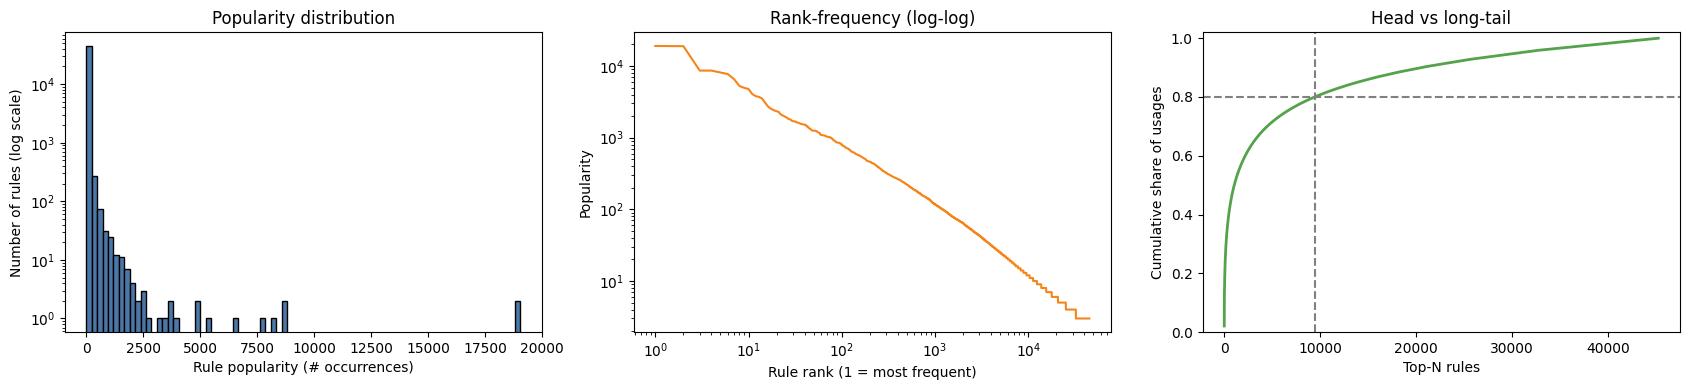

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

reactions_path = "../mapping/uspto_full_rules_light_pop_3_uu.tsv"  # adjust path as needed
# expects: reactions_path points to your rules TSV
# columns usually: rule_smarts, popularity, reaction_indices
df = pd.read_csv(reactions_path, sep="\t")
print(df.shape)
# robust popularity extraction
if "reaction_indices" in df.columns:
    pop_from_idx = df["reaction_indices"].fillna("").map(
        lambda s: 0 if s == "" else s.count(",") + 1
    )
else:
    pop_from_idx = pd.Series([np.nan] * len(df), index=df.index)

if "popularity" in df.columns:
    pop = pd.to_numeric(df["popularity"], errors="coerce")
else:
    pop = pd.Series([np.nan] * len(df), index=df.index)

df["popularity"] = pop.fillna(pop_from_idx).astype(int)

# rank-frequency and head/tail split
rank_pop = df["popularity"].sort_values(ascending=False).reset_index(drop=True)
total_uses = int(rank_pop.sum())
cum_share = rank_pop.cumsum() / total_uses
head_n = int((cum_share < 0.80).sum() + 1)  # minimal rules covering >=80% usage

print(f"Rules: {len(df):,}")
print(f"Total rule usages: {total_uses:,}")
print(f"Median popularity: {df['popularity'].median():.0f}")
print(f"Max popularity: {df['popularity'].max():,}")
print(f"Head (80% coverage): {head_n:,} rules ({100*head_n/len(df):.2f}% of rules)")

display(df["popularity"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("popularity"))
display(df.nlargest(20, "popularity")[["rule_smarts", "popularity"]])

fig, ax = plt.subplots(1, 3, figsize=(17, 4))

# 1) histogram
ax[0].hist(df["popularity"], bins=80, log=True, color="#4c78a8", edgecolor="black")
ax[0].set_xlabel("Rule popularity (# occurrences)")
ax[0].set_ylabel("Number of rules (log scale)")
ax[0].set_title("Popularity distribution")

# 2) rank-frequency (long-tail)
ax[1].plot(np.arange(1, len(rank_pop) + 1), rank_pop.values, lw=1.5, color="#f58518")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Rule rank (1 = most frequent)")
ax[1].set_ylabel("Popularity")
ax[1].set_title("Rank-frequency (log-log)")

# 3) cumulative coverage (head vs tail)
ax[2].plot(np.arange(1, len(rank_pop) + 1), cum_share.values, lw=2, color="#54a24b")
ax[2].axhline(0.80, ls="--", color="gray")
ax[2].axvline(head_n, ls="--", color="gray")
ax[2].set_xlabel("Top-N rules")
ax[2].set_ylabel("Cumulative share of usages")
ax[2].set_title("Head vs long-tail")
ax[2].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()


In [ ]:
from chython import smarts
from chython.containers import ReactionContainer


def load_tsv_rules_as_reaction_containers(tsv_path: str) -> tuple[ReactionContainer, ...]:
    rules = []
    with open(tsv_path, encoding="utf-8") as f:
        f.readline()  # skip header
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            rule_smarts = line.split("\t", 1)[0]
            rule = smarts(rule_smarts)
            rules.append(rule)
    return tuple(rules)


reactions_path_a = "../mapping/uspto_full_rules_light_pop_3_uu.tsv"
reactions_path_b = "../mapping/uspto_full_rules_light_pop_3_uuu.tsv"

x = load_tsv_rules_as_reaction_containers(reactions_path_a)
y = load_tsv_rules_as_reaction_containers(reactions_path_b)

In [ ]:
a_q = []
errors_a = []
for aa in tqdm(list(data_a)):
    try:
        q = smarts(aa)
        cq = ~q
        a_q.append((q, cq))
    except IncorrectSmiles:
        errors_a.append(aa)